In [1]:
import numpy as np

# --- 1. Define Dimensions ---
Nx = 384 - 12
Ny = 512 - 12
Nz = 512 - 12

# Initialize the volume with 1s (Background). uint8 saves memory.
vol = np.ones((Nx, Ny, Nz), dtype=np.uint8)

thickness = 12       # Diameter of the cylinder
radius = thickness / 2.0

# 5 uniformly spaced positions 
# (subtracting 1 to convert MATLAB's 1-based to Python's 0-based index)
xpos = np.round(np.linspace(40, Nx - thickness - 40, 5)).astype(int) - 1
ypos = np.round(np.linspace(30, Ny - thickness - 30, 5)).astype(int) - 1

# --- 2. Create a 3D Cylindrical Mask ---
# Create a 2D local grid (indexing='ij' matches MATLAB's ndgrid)
xx, yy = np.meshgrid(np.arange(1, thickness + 1), 
                     np.arange(1, thickness + 1), 
                     indexing='ij')
xc = radius + 0.5
yc = radius + 0.5

# 2D circular mask using the circle equation
circle_mask_2D = ((xx - xc)**2 + (yy - yc)**2) <= radius**2

# Expand the 2D mask into a 3D cylinder that stretches across the Z axis
# Add a new axis and repeat it Nz times
circle_mask_3D = np.repeat(circle_mask_2D[:, :, np.newaxis], Nz, axis=2)

# --- 3. Place 25 Rods (5x5) ---
for ky in range(5):
    # Zig-zag ordering in X as Y increases
    # In Python, ky=0,2,4 are the "odds" if we compare to MATLAB's 1,3,5
    if ky % 2 == 0:
        xorder = list(range(5))          # left -> right
    else:
        xorder = list(range(4, -1, -1))  # right -> left
        
    y = ypos[ky]
    
    for kx in range(5):
        x = xpos[xorder[kx]]
        
        # Extract the current background subvolume (all Z slices)
        sub_vol = vol[x:x+thickness, y:y+thickness, :]
        
        # Apply the blood material (2) using boolean masking
        sub_vol[circle_mask_3D] = 2
        
        # Place updated subvolume back into the main volume
        vol[x:x+thickness, y:y+thickness, :] = sub_vol

# Now 'vol' contains your 3D array

C:\Users\vsb27\AppData\Local\Temp\ipykernel_20020\2689078215.py:32: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


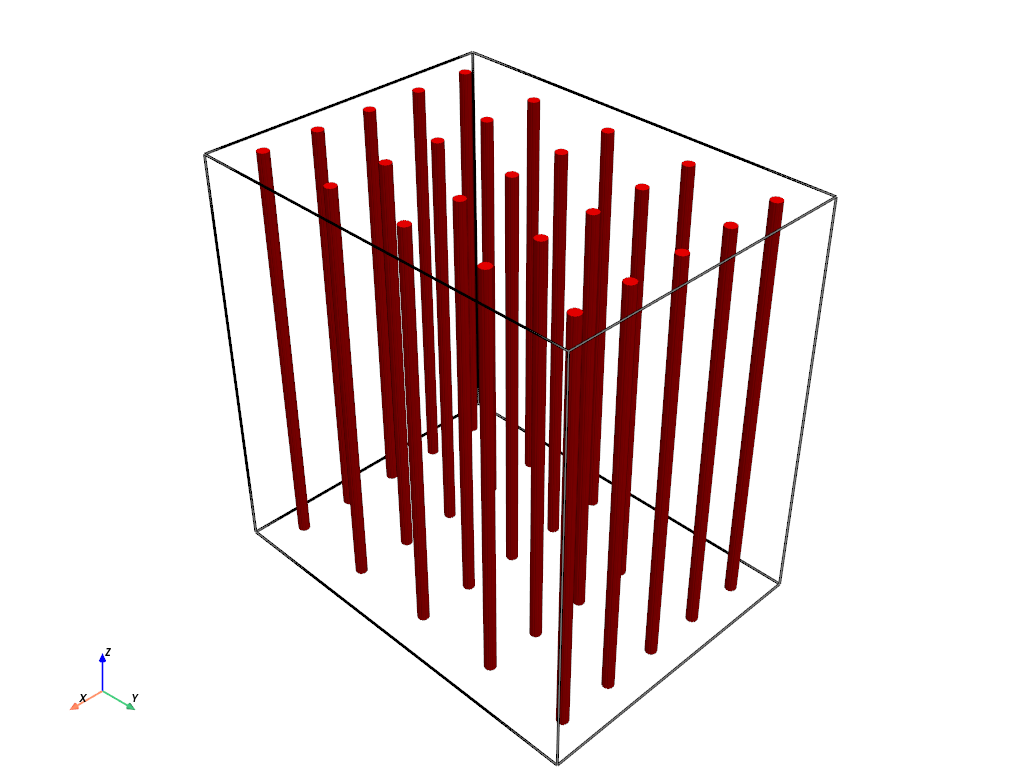

In [2]:
import pyvista as pv

# 1. Map the NumPy array to a PyVista spatial grid
grid = pv.ImageData(dimensions=vol.shape)

# Flatten in Fortran order ('F') to match PyVista/VTK memory layout
grid.point_data["Materials"] = vol.flatten(order="F")

# 2. Extract ONLY the blood rods (where value == 2)
# We use a threshold to hide the background (1s)
rods = grid.threshold([1.5, 2.5])

# 3. Setup the Plotter (Publication Quality)
plotter = pv.Plotter()
plotter.background_color = "white"

# Add the rods to the plot
plotter.add_mesh(rods, color="red", smooth_shading=True, label="Blood Vessels")

# Add the "3D Box" (bounding box) around the entire volume space
plotter.add_mesh(grid.outline(), color="black", line_width=3)

# Add clear axes and a scale
plotter.show_axes()
plotter.add_bounding_box(color="gray", line_width=1)

# 4. Display and Save
# Uncomment the line below to save a high-res image for your paper. 
# scale=3 multiplies the window resolution by 3.
# plotter.screenshot("volume_render_high_res.png", scale=3) 

plotter.show()